# L1 и L2 регуляризация
### Как укротить модель, которая «слишком старается»

---

Представьте: вы учите ребёнка распознавать фрукты.

Показываете 5 яблок — он запоминает: «красное, круглое, с хвостиком слева, 7 см в диаметре».

Приносите новое яблоко — а оно зелёное! Ребёнок в замешательстве: *«Это не яблоко, оно не красное!»*

> Он **переобучился** — запомнил детали вместо общей идеи.

Регуляризация учит модель не цепляться за каждую мелочь.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_regression

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BLUE   = '#4C72B0'
RED    = "#CE0C12"
PURPLE = '#9467bd'

## Часть 1. Проблема: взрывные веса и мусорные признаки

Задача: предсказать цену квартиры по 10 признакам.
Но у нас всего 15 квартир в обучающей выборке.

Модель подбирает веса так, чтобы **идеально** угадать все 15 цен.
Но... У нас маленькая проблема... Модель переобучается и учитывает даже мусор.

In [ ]:
true_weights = np.array([5, -2, 1.5, 0, 6, 0, 0, 7, 0, -5])
overfitted_weights = np.array([8, -12, 5, 15, -18, 9, -7, 11, 6, -10])


feature_names = ['площадь', 'этаж', 'район', 'балкон', 'лифт',
                 'парковка', 'год', 'окна', 'ремонт', 'подъезд']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(range(10), true_weights, color=BLUE, alpha=0.8,
              edgecolor='white', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
ax.set_ylim(-20, 20)
ax.set_title('Истинные веса\n', fontsize=12, fontweight='bold', color=BLUE)
ax.set_xticks(range(10))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)


ax = axes[1]
bars = ax.bar(range(10), overfitted_weights, color=RED, alpha=0.8,
              edgecolor='white', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
ax.set_ylim(-20, 20)
ax.set_title('Без регуляризации (переобучение)\n', fontsize=12, fontweight='bold', color=RED)
ax.set_xticks(range(10))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)

plt.suptitle('Проблема: без регуляризации модель назначает огромные веса всем признакам',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Часть 2. Идея регуляризации — что это?

Представим вас инвестором. У вас 1 млн руб. и 10 возможных активов. Задача наиболее грамотно их распределить. Путем сложной математики вы нашли две оптимальные стратегии

Ridge: диверсификация — вы раскидываете во все активы деньги, стараясь избегать слишком больших вложений

Lasso: концентрация — вы фокусируетесь только на некоторых, отвечающих вашим интересам, остальные не учитываете


По сути, это и есть регуляризация. Ridge (L2) шштрафует модель за слишком большие веса, а Lasso (L1) штрафует за каждый ненулевой вес (то есть подталкивает модель обнулять некоторые веса)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
items_ridge = {'Футболки': 2, 'Книги': 5, 'Обувь': 3, 'Гаджеты': 4, 'Косметика': 1}
colors_ridge = BLUE
bars = ax.barh(list(items_ridge.keys()), list(items_ridge.values()),
               color=colors_ridge, alpha=0.7, edgecolor='white', linewidth=2)
ax.set_xlabel('Количество вещей', fontsize=11)
ax.set_title('Ridge (L2): всё понемногу', fontsize=12, fontweight='bold', color=BLUE)
ax.set_xlim(0, 12)

for i, (item, val) in enumerate(items_ridge.items()):
    ax.text(val + 0.3, i, str(val), va='center', fontsize=10, fontweight='bold')




ax = axes[1]
colors_ridge = RED
items_lasso = {'Футболки': 7, 'Книги': 0, 'Обувь': 6, 'Гаджеты': 0, 'Косметика': 0}
bars = ax.barh(list(items_lasso.keys()), list(items_lasso.values()),
               color=colors_ridge, alpha=0.7, edgecolor='white', linewidth=2)
ax.set_xlabel('Количество вещей', fontsize=11)
ax.set_title('Lasso (L1): только главное', fontsize=12, fontweight='bold', color=RED)
ax.set_xlim(0, 12)

for i, (item, val) in enumerate(items_lasso.items()):
    ax.text(val + 0.3, i, str(val), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 🔵 Часть 3. Ridge (L2) — уменьшает ВСЕ веса

**Штраф:** сумма квадратов весов → `w₁² + w₂² + ... + wₙ²`

**λ (лямбда)** — насколько сильно штрафуем:
- λ маленькое → почти как без регуляризации
- λ большое → веса стремятся к нулю

In [ ]:
original_weights = np.array([50, 40, 25, 18, 12, 8, 5, 3, 2, 1])

ridge_weak   = original_weights * 0.9
ridge_medium = original_weights * 0.6
ridge_strong = original_weights * 0.3


fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

ridge_data = [
    (original_weights, 'Исходные веса\n(λ = 0)'),
    (ridge_weak, 'Ridge слабый\n(λ маленькое)'),
    (ridge_medium, 'Ridge средний\n(λ среднее)'),
    (ridge_strong, 'Ridge сильный\n(λ большое)')
]

for ax, (weights, title) in zip(axes, ridge_data):
    bars = ax.bar(range(10), weights, color=BLUE, alpha=0.75,
                  edgecolor='white', linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
    ax.set_ylim(0, 55)
    ax.set_title(title, fontsize=10, fontweight='bold', color=BLUE)
    ax.set_xlabel('Признак', fontsize=9)
    if ((ax == axes[0]) or (ax == axes[2])):
        ax.set_ylabel('Вес', fontsize=10)
    ax.set_xticks(range(10))
    ax.set_xticklabels([f'{i+1}' for i in range(10)], fontsize=9)

plt.show()

---
## 🔴 Часть 4. Lasso (L1) — обнуляет ненужные веса

**Штраф:** сумма модулей весов → `|w₁| + |w₂| + ... + |wₙ|`

Здесь так же есть Лямбда, отвечающая за "величину штрафа"

**Но есть и бонус! Вот:**
> Lasso **обнуляет** слабые признаки. А то и вовсе мусорные. Что дает нам подбирать нужные признаки!

In [ ]:
original_weights = np.array([50, 40, 25, 18, 12, 8, 0, 0, 0, 0])

lasso_weak = np.array([49, 39, 24, 17, 11, 7, 4, 2, 1, 0])
lasso_medium = np.array([45, 35, 20, 13, 7, 3, 0, 0, 0, 0])
lasso_strong = np.array([35, 25, 10, 4, 0, 0, 0, 0, 0, 0])

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)

lasso_data = [
    (original_weights, 'Исходные веса\n(λ = 0)'),
    (lasso_weak, 'Lasso слабый\n(λ маленькое)'),
    (lasso_medium, 'Lasso средний\n(λ среднее)'),
    (lasso_strong, 'Lasso сильный\n(λ большое)')
]

for ax, (weights, title) in zip(axes, lasso_data):
    bars = ax.bar(range(10), weights, color=RED, alpha=0.75,
                  edgecolor='white', linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)

    ax.set_ylim(0, 55)

    ax.set_title(title, fontsize=10, fontweight='bold', color=RED)
    ax.set_xlabel('Признак', fontsize=9)

    if ax == axes[0] or ax == axes[2]:
        ax.set_ylabel('Вес', fontsize=10)
    ax.set_xticks(range(10))
    ax.set_xticklabels([f'{i+1}' for i in range(10)], fontsize=9)

plt.tight_layout()
plt.show()

#### А что насчет отбора признаков?

Сгненрируем датасет из 50 признаков, притом важными из них сделаем только первые 5, и обучим модель на таком

In [ ]:
np.random.seed(7)
n_samples_big = 50
n_features_big = 50
n_important = 5

X_big = np.random.randn(n_samples_big, n_features_big)
true_weights_big = np.zeros(n_features_big)
true_weights_big[:n_important] = [5, -3, 2, -1.5, 1]
y_big = X_big @ true_weights_big + np.random.randn(n_samples_big) * 1

lasso_select = Lasso(alpha=0.2, max_iter=5000)
lasso_select.fit(X_big, y_big)
weights_selected = lasso_select.coef_

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(range(n_features_big), weights_selected,
              color=RED, alpha=0.75, edgecolor='white', linewidth=1)

ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
ax.set_xlim(-1, n_features_big)

plt.show()

## 🟣 Часть 5. Когда что использовать?

Вообще-то говоря, здесь мы можем использовать универсальное правило -- определи через кросс-валидацию. И, честно говоря, это единственно правильный ответ для этого вопроса в общем виде. И L1, и L2 отлично выполняют свои задачи, если их правильно применять. И когда мы сталкиваемся с выбором, мы должны в первую очередь смотреть на данные, и, если все еще непонятно, проводить кросс-валидацию. Но кое-какие правила для отбора мы вывести сможем

### Простое правило выбора

**Вопрос 1: У вас много признаков?**

**→ ДА** — переходите к вопросу 2  
**→ НЕТ** — скорее всего **Ridge**

---

**Вопрос 2: Много из них мусорные (шумовые)?**

**→ ДА** — используйте **Lasso (L1)**  
- ✅ Обнулит мусор автоматически  
- ✅ Покажет что реально работает  
- ✅ Упростит модель  

**→ НЕТ** — используйте **Ridge (L2)**  
- ✅ Использует все признаки  
- ✅ Уменьшит веса, но никого не выкинет  
- ✅ Более стабильная модель  

**→ Неизвестно** — используйте **CV**  
- ✅ Даст четкий ответ, какая из двух регуляризаций вам подходит
- ✅ Поможет подобрать гипер-параметры
- ✅ Ну и скажет насколько именно
---

### Немного кейсов где что использовать

| Ситуация | Выбор | Почему |
|---|---|---|
| У вас 100 признаков, 50 из них мусор | **Lasso** | Обнулит мусор автоматически |
| У вас 10 признаков, все полезны | **Ridge** | Уменьшит все, никого не выкинет |
| Не знаете, какие признаки важны | **Lasso** | Покажет что работает |
| Нужна стабильность и гладкость | **Ridge** | Мягче, меньше скачков |
| Хотите упростить модель | **Lasso** | Меньше признаков = проще |

---


> **Реймайндер!** Кросс-валидацию все еще доступна как опция, в случае если вы не уверены, что вам подходит! Вообще-то говоря, ее можно вообще всегда проводить, ошибкой такой подход не будет

## Пример использования CV для подбора λ

> **Если вкратце:** λ подбирается кросс-валидацией -- просто перебираем варианты и смотрим на ошибку.

In [ ]:
alphas_test = np.logspace(-3, 2, 30)
ridge_scores = []
lasso_scores = []

for alpha in alphas_test:
    ridge_model = Ridge(alpha=alpha)
    lasso_model = Lasso(alpha=alpha, max_iter=5000)

    ridge_score = -cross_val_score(ridge_model, X_big, y_big, cv=5,
                                     scoring='neg_mean_squared_error').mean()
    lasso_score = -cross_val_score(lasso_model, X_big, y_big, cv=5,
                                     scoring='neg_mean_squared_error').mean()

    ridge_scores.append(ridge_score)
    lasso_scores.append(lasso_score)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(alphas_test, ridge_scores, color=BLUE, lw=2.5, marker='o',
        markersize=4, label='Ridge')
ax.plot(alphas_test, lasso_scores, color=RED, lw=2.5, marker='s',
        markersize=4, label='Lasso')


best_ridge_idx = np.argmin(ridge_scores)
best_lasso_idx = np.argmin(lasso_scores)

ax.scatter([alphas_test[best_ridge_idx]], [ridge_scores[best_ridge_idx]],
           color=PURPLE, s=200, marker='.', zorder=5, edgecolors='white', linewidths=2)
ax.scatter([alphas_test[best_lasso_idx]], [lasso_scores[best_lasso_idx]],
           color=PURPLE, s=200, marker='.', zorder=5, edgecolors='white', linewidths=2)

ax.set_xscale('log')
ax.set_xlabel('λ (сила регуляризации)', fontsize=12)
ax.set_ylabel('Ошибка (MSE)', fontsize=12)
ax.set_title('Кросс-валидация: ищем λ с минимальной ошибкой',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Оптимум Ridge: λ = {alphas_test[best_ridge_idx]:.3f}')
print(f'Оптимум Lasso: λ = {alphas_test[best_lasso_idx]:.3f}')
print('\nВ sklearn есть готовые классы RidgeCV и LassoCV — они сами подбирают λ')

---
## Вопросы для самопроверки



Вопрос 1: Зачем нужна регуляризация? Какую проблему решает регуляризация в машинном обучении?  - Регуляризация решает проблему переобучения. Она штрафует модель за излишнюю сложность, не давая ей слишком сильно подстраиваться под шум в данных. В результате модель становится более простой, устойчивой и лучше обобщается на новые данные.

Вопрос 2: Что делает Ridge (L2)? Что делает Lasso (L1)?
Ridge : Добавляет штраф, пропорциональный квадрату весов. Она уменьшает веса, делая их близкими к нулю, но не обнуляет их полностью. Хороша, когда все признаки важны.

Lasso : Добавляет штраф, пропорциональный модулю весов. Она может обнулять неважные признаки, фактически удаляя их из модели. Хороша для отбора признаков.

Вопрос 3: За что отвечает λ (лямбда) и как его выбирать? - λ отвечает за силу регуляризации: чем больше λ, тем сильнее штраф за сложность и тем меньше веса модели. Выбирать λ лучше по валидации или кросс-валидации; если модель переобучается, λ увеличивают, если недообучается — уменьшают.

Вопрос 4: Как правильно подобрать метод регуляризации? Исключая очевидный вариант -- CV -

Если признаков мало и все важны → Ridge

Если признаков много и есть подозрение на неважные → Lasso

Если признаки сильно коррелируют и одновременно нужны стабильность и отбор признаков → Elastic Net



Вопрос 5: Lasso в некотором роде помогает нам с отбором признаков. Почему и как? - Lasso использует L1-штраф, который может доводить коэффициенты слабых или шумовых признаков ровно до нуля. Признаки с нулевыми коэффициентами фактически исключаются из модели, поэтому Lasso одновременно обучает модель и выполняет автоматический отбор признаков.


**Вопрос 1: Регуляризация**
#Регуляризация используется для борьбы с переобучением

Модель с большим числом параметров может:

- слишком точно подстроиться под обучающую выборку,
- начать описывать шум,
- потерять способность обобщать на новые данные

Формально это проявляется как:
- низкая ошибка на train,
-высокая ошибка на test.

Регуляризация добавляет к функции потерь дополнительный штраф за сложность модели,
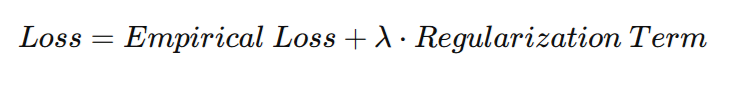

тем самым:
- ограничивается величина весов,
- уменьшается дисперсия модели,
- повышается устойчивость,
- улучшается обобщающая способность.

Регуляризация — это способ контролировать баланс bias–variance

**Вопрос 2. Что делает Ridge (L2)? Что делает Lasso (L1)?**

Ridge (L2-регуляризация)

Добавляет штраф:

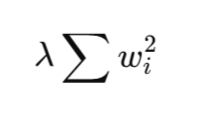
	​

Эффект:

веса уменьшаются,

становятся "сглаженными",

но практически никогда не становятся строго равными нулю.

**Когда подходит:**

признаки коррелированы,

все признаки потенциально важны,

нужно уменьшить variance, но не делать feature selection.

Ridge особенно устойчив при мультиколлинеарности.

Lasso (L1-регуляризация)

Добавляет штраф:

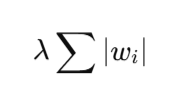

**Эффект:**

некоторые веса становятся строго равными нулю,

модель автоматически выполняет отбор признаков.

Когда подходит:

признаков много,

ожидается разреженная модель,

есть шумовые или лишние признаки.



**Вопрос 3. За что отвечает λ (лямбда) и как его выбирать?**

λ (регуляризационный коэффициент) управляет силой штрафа за сложность.

Малое λ → слабая регуляризация → риск переобучения

Большое λ → сильная регуляризация → риск недообучения

Если λ → 0:
получаем обычную регрессию без регуляризации.

Если λ → ∞:
веса стремятся к нулю.

**Как выбирать λ?**

Основной способ — подбор по валидации (CV).
Но концептуально:

если модель переобучается → увеличить λ

если модель недообучается → уменьшить λ

 λ — это параметр контроля bias–variance trade-off

**Вопрос 4. Как правильно подобрать метод регуляризации (кроме CV)?**

Метод выбирается исходя из структуры данных.

*Если:*

признаков мало,

все признаки значимы,

есть мультиколлинеарность
→ Ridge

*Если:*

признаков много,

предполагается разреженная зависимость,

есть шумовые признаки
→ Lasso

*Если:*

есть группы коррелированных признаков,

нужна и стабильность, и отбор
→ Elastic Net (комбинация L1 + L2)

Elastic Net часто предпочтительнее Lasso при сильной корреляции признаков, потому что Lasso может случайно выбрать один признак из группы.

**Вопрос 5. Почему и как Lasso помогает с отбором признаков?**

Ключ — в геометрии L1-нормы

Математически

L1-регуляризация добавляет штраф:

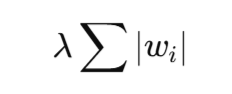

Этот штраф имеет "угловую" геометрию (ромб в 2D), из-за чего оптимальное решение часто попадает в вершины, где один или несколько коэффициентов равны нулю.

Интуитивно

L1-шраф:

делает малые веса слишком «дорогими»,

если вклад признака в снижение ошибки небольшой,
модели выгоднее занулить вес полностью.

**Таким образом:**

нерелевантные признаки получают вес 0,

модель становится разреженной (sparse),

уменьшается размерность,

повышается интерпретируемость.

Это встроенный механизм feature selection.

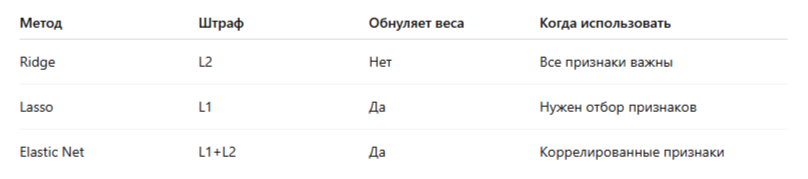